# Taller: Modelos de Clasificación - Predicción de Envíos en E-Commerce
 
En este notebook encontrarán la estructura general para desarrollar el modelo predictivo de retrasos en los envíos. Sigan las instrucciones de cada sección y completen el código correspondiente.

In [17]:
# Paso 0: Importación de librerías esenciales

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics)

In [18]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle

# Cargar el conjunto de datos
df = pd.read_csv("Train.csv")

# Número de filas y columnas
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# Mostrar las primeras filas
df.head()
# Información general
df.info()
# Estadísticas descriptivas
df.describe()
# Valores nulos por columna
df.isnull().sum()
#Variables categóricas
df.describe(include="object")

# TIP: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.


El dataset tiene 10999 filas y 12 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.1 MB


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2964\2069401294.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Warehouse_block,Mode_of_Shipment,Product_importance,Gender
count,10999,10999,10999,10999
unique,5,3,3,2
top,F,Ship,low,F
freq,3666,7462,5297,5545


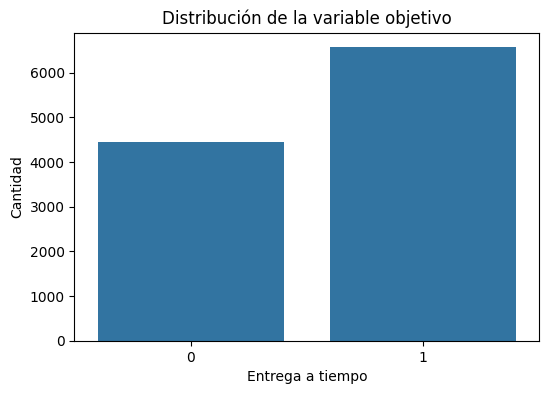

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Reached.on.Time_Y.N")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Entrega a tiempo")
plt.ylabel("Cantidad")
plt.show()

## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

### Selección de variables

Antes de realizar el preprocesamiento se elimina la columna **ID**, ya que corresponde únicamente a un identificador de cada registro y no aporta información relevante para el proceso de clasificación. Posteriormente, se separan las variables predictoras de la variable objetivo.

In [20]:
# Eliminar la columna ID
df = df.drop(columns=["ID"])

# Variables predictoras
X = df.drop(columns=["Reached.on.Time_Y.N"])

# Variable objetivo
y = df["Reached.on.Time_Y.N"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (10999, 10)
Dimensiones de y: (10999,)


In [21]:
# Dividir el conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (8799, 10)
Datos de prueba: (2200, 10)


In [22]:
#Paso 2: Identificación y transformación de variables categóricas

# TIP 1 (Encoding Ordinal): Analicen la columna 'Product_importance'. ¿Tiene un orden lógico?
# Apliquen una estrategia que conserve esa jerarquía (ej. low=1, medium=2, high=3).

# Analizar los valores de la variable Product_importance
print(df["Product_importance"].unique())

# Transformar la variable ordinal
df["Product_importance"] = df["Product_importance"].map({
    "low": 1,
    "medium": 2,
    "high": 3
})

# Verificar la transformación
df["Product_importance"].head()

# TIP 2 (One-Hot Encoding): Analicen las columnas 'Mode_of_Shipment' y 'Warehouse_block'.
# Al no tener un orden lógico, utilicen One-Hot Encoding (pd.get_dummies o OneHotEncoder).

# Analizar los valores de las variables categóricas
print(df["Mode_of_Shipment"].unique())
print(df["Warehouse_block"].unique())

# Aplicar One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["Mode_of_Shipment", "Warehouse_block"],
    drop_first=True
)

# Verificar el resultado
df.head()

# Transformar la variable Gender
print(df["Gender"].unique())

df["Gender"] = df["Gender"].map({
    "F": 0,
    "M": 1
})

# Verificar la transformación
df["Gender"].head()

# TIP 3: Recuerden definir claramente su matriz de características (X) y el vector objetivo (y).
# El target para este problema es la columna 'Reached.on.Time_Y.N'.

# Definir la matriz de características (X) y el vector objetivo (y)
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

# Verificar las dimensiones
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

<ArrowStringArray>
['low', 'medium', 'high']
Length: 3, dtype: str
<ArrowStringArray>
['Flight', 'Ship', 'Road']
Length: 3, dtype: str
<ArrowStringArray>
['D', 'F', 'A', 'B', 'C']
Length: 5, dtype: str
<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
Dimensiones de X: (10999, 14)
Dimensiones de y: (10999,)


## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [23]:
# Paso 3: Train/Test Split
# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables.

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificar las dimensiones de los conjuntos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8799, 14)
X_test: (2200, 14)
y_train: (8799,)
y_test: (2200,)


## 4. Entrenamiento de Modelos
 
Deben seleccionar, entrenar y evaluar tres algoritmos de clasificación distintos (por ejemplo: Regresión Logística, Árboles de Decisión, Random Forest, KNN, etc.).

Accuracy: 0.6404545454545455

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.64      0.64      2200



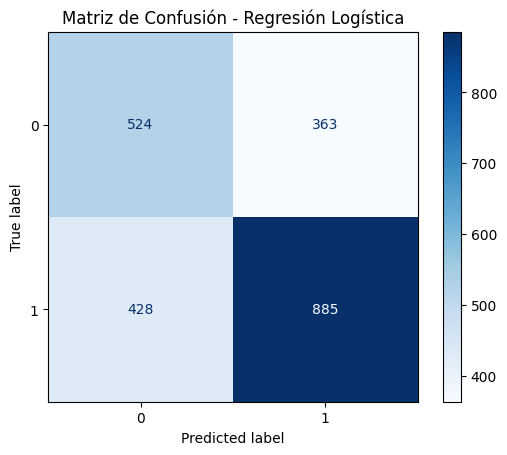

In [33]:
## Paso 4: Entrenamiento y evaluación de modelos

# Escalado de las variables numéricas
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

# Columnas numéricas
columnas_numericas = [
    "Customer_care_calls",
    "Customer_rating",
    "Cost_of_the_Product",
    "Prior_purchases",
    "Discount_offered",
    "Weight_in_gms",
    "Product_importance"
]

# Ajustar el escalador con los datos de entrenamiento
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])

# Transformar los datos de prueba
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test

# Importar el modelo
from sklearn.linear_model import LogisticRegression

# Instanciar el modelo
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)

# Entrenar el modelo
modelo_lr.fit(X_train, y_train)

# Realizar predicciones
y_pred_lr = modelo_lr.predict(X_test)

# Evaluación del modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.show()


# La Regresión Logística obtuvo un Accuracy de 64.05 %, mostrando un desempeño aceptable para el problema de clasificación. 
# Sin embargo, el modelo presenta una mejor capacidad para identificar los pedidos de la clase 1 que los de la clase 0, como se observa en las métricas de precisión, recall y F1-score.



Accuracy: 0.6331818181818182

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.52      0.53       887
           1       0.69      0.71      0.70      1313

    accuracy                           0.63      2200
   macro avg       0.62      0.61      0.62      2200
weighted avg       0.63      0.63      0.63      2200



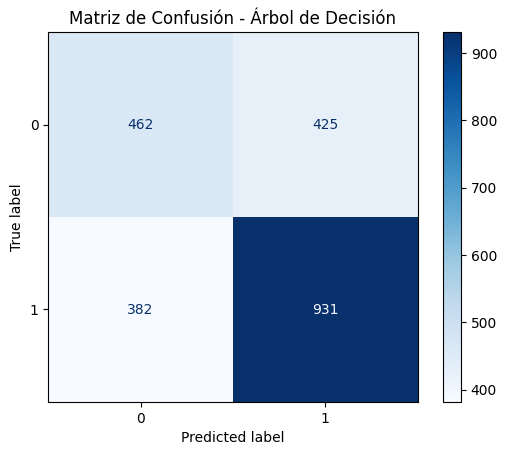

In [34]:
# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test

# Importar el modelo
from sklearn.tree import DecisionTreeClassifier

# Instanciar el modelo
modelo_dt = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
modelo_dt.fit(X_train, y_train)

# Realizar predicciones
y_pred_dt = modelo_dt.predict(X_test)

# Evaluación del modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

Accuracy: 0.6477272727272727

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.70      0.61       887
           1       0.75      0.61      0.68      1313

    accuracy                           0.65      2200
   macro avg       0.65      0.66      0.65      2200
weighted avg       0.67      0.65      0.65      2200



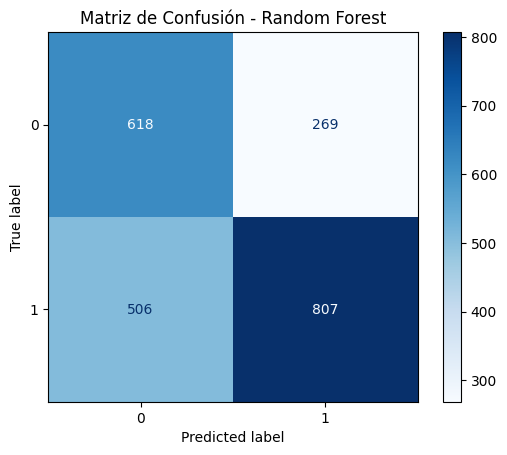

In [35]:
# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test

# Importar el modelo
from sklearn.ensemble import RandomForestClassifier

# Instanciar el modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# Realizar predicciones
y_pred_rf = modelo_rf.predict(X_test)

# Evaluación del modelo
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

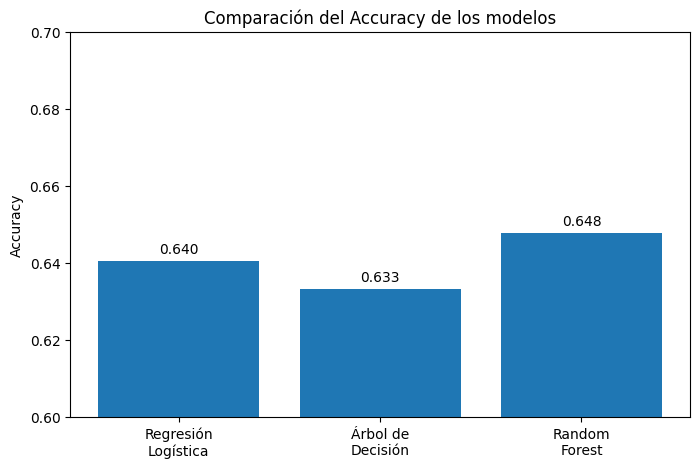

In [31]:
# Comparación de modelos
import matplotlib.pyplot as plt

modelos = ["Regresión\nLogística", "Árbol de\nDecisión", "Random\nForest"]
accuracy = [0.6405, 0.6332, 0.6477]

plt.figure(figsize=(8,5))
plt.bar(modelos, accuracy)

plt.title("Comparación del Accuracy de los modelos")
plt.ylabel("Accuracy")
plt.ylim(0.60, 0.70)

# Mostrar el valor sobre cada barra
for i, valor in enumerate(accuracy):
    plt.text(i, valor + 0.002, f"{valor:.3f}", ha="center")

plt.show()

## Conclusiones

Se entrenaron y evaluaron tres modelos de clasificación: Regresión Logística, Árbol de Decisión y Random Forest. La comparación se realizó utilizando el Accuracy, el Classification Report y la Matriz de Confusión.

El modelo Random Forest obtuvo el mejor desempeño, alcanzando un Accuracy de 64.77 %, superior al de la Regresión Logística (64.05 %) y al Árbol de Decisión (63.32 %). Además, presentó un equilibrio adecuado entre precisión y capacidad de clasificación de las dos clases, lo que lo convierte en el modelo más apropiado para este conjunto de datos.

En conclusión, el modelo Random Forest fue seleccionado como el mejor para predecir si un pedido llegará a tiempo, ya que obtuvo el mayor rendimiento entre los tres modelos evaluados.

## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

===== REGRESIÓN LOGÍSTICA =====
Accuracy: 0.6404545454545455

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.64      0.64      2200



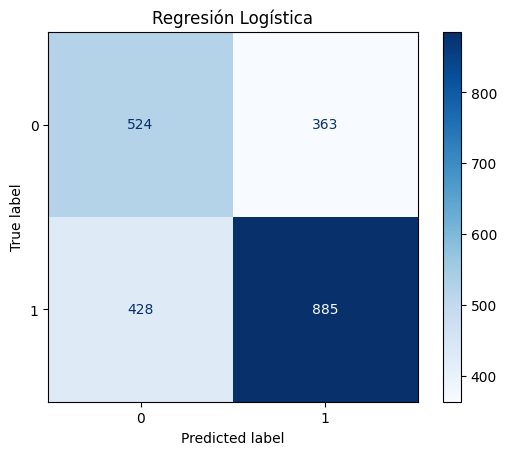

===== ÁRBOL DE DECISIÓN =====
Accuracy: 0.6331818181818182

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.52      0.53       887
           1       0.69      0.71      0.70      1313

    accuracy                           0.63      2200
   macro avg       0.62      0.61      0.62      2200
weighted avg       0.63      0.63      0.63      2200



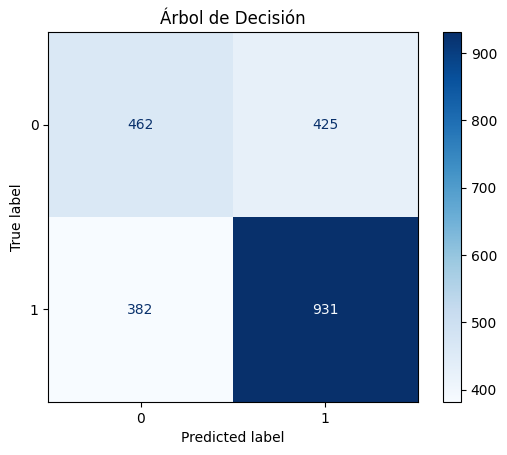

===== RANDOM FOREST =====
Accuracy: 0.6477272727272727

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.70      0.61       887
           1       0.75      0.61      0.68      1313

    accuracy                           0.65      2200
   macro avg       0.65      0.66      0.65      2200
weighted avg       0.67      0.65      0.65      2200



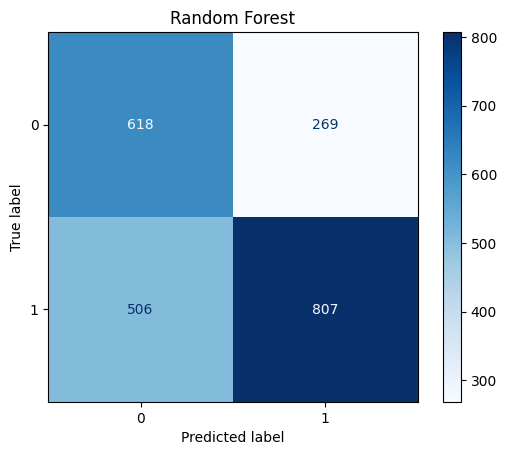

In [37]:
# Paso 5: Cálculo de métricas para cada modelo por medio de accuracy_score, confusion_matrix, classification_report, etc.
# TIP: Almacenen los resultados de Accuracy en un diccionario o DataFrame para facilitar la graficación.

# Calcular el Accuracy de cada modelo
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Guardar los resultados en un diccionario
resultados = {
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
}

resultados_df = pd.DataFrame(resultados)

resultados_df

print("===== REGRESIÓN LOGÍSTICA =====")

print("Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Regresión Logística")
plt.show()

print("===== ÁRBOL DE DECISIÓN =====")

print("Accuracy:", accuracy_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues"
)

plt.title("Árbol de Decisión")
plt.show()

print("===== RANDOM FOREST =====")

print("Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest")
plt.show()


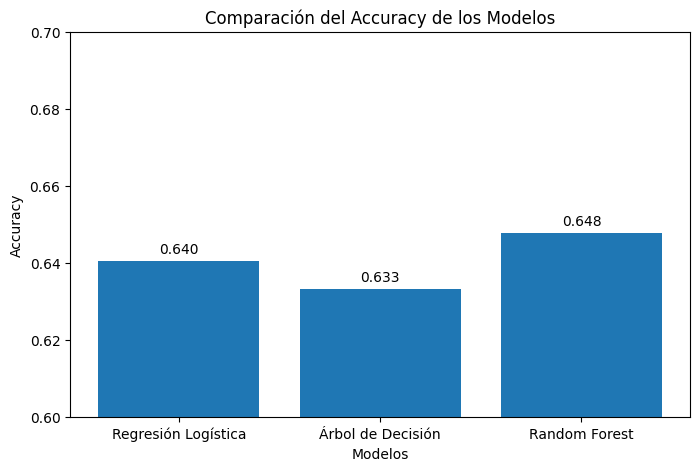

In [38]:
# Paso 6: Gráfica comparativa de Accuracy
# TIP: Utilicen un gráfico de barras (sns.barplot o plt.bar) donde el eje X sean los modelos
# y el eje Y sea el valor de Accuracy obtenido.

# Crear la gráfica comparativa de Accuracy
plt.figure(figsize=(8,5))

plt.bar(resultados_df["Modelo"], resultados_df["Accuracy"])

plt.title("Comparación del Accuracy de los Modelos")
plt.xlabel("Modelos")
plt.ylabel("Accuracy")
plt.ylim(0.60, 0.70)

# Mostrar el valor de Accuracy sobre cada barra
for i, valor in enumerate(resultados_df["Accuracy"]):
    plt.text(i, valor + 0.002, f"{valor:.3f}", ha="center")

plt.show()

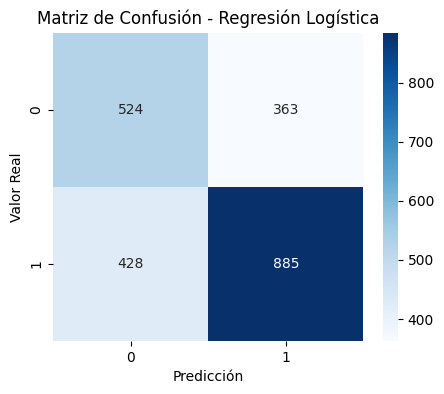

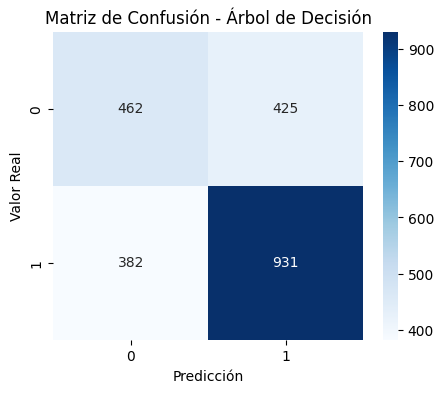

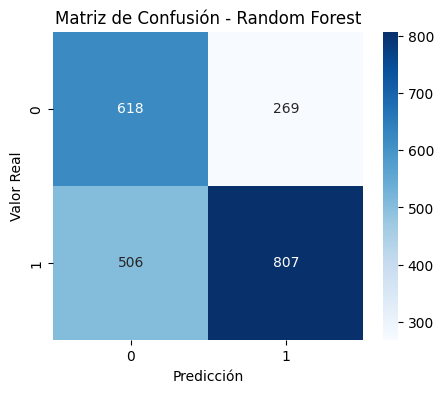

In [39]:
# Paso 7: Matrices de Confusión
# TIP: Generen y visualicen la matriz de confusión para cada uno de los tres modelos utilizando sns.heatmap.
# Esto les permitirá analizar visualmente los falsos positivos y falsos negativos de cada algoritmo.

# Matriz de confusión - Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

# Matriz de confusión - Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

# Matriz de confusión - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

## Conclusión

En este taller se aplicaron técnicas de preprocesamiento de datos, incluyendo la codificación de variables categóricas y el escalado de variables numéricas. Posteriormente, se entrenaron tres modelos de aprendizaje supervisado para predecir si un envío llegaría a tiempo.

Los modelos fueron evaluados mediante Accuracy, Classification Report y Matrices de Confusión. Después de comparar los resultados, se concluyó que Random Forest obtuvo el mejor desempeño, con un Accuracy de 64.77 %, por lo que fue seleccionado como el modelo más adecuado para este problema de clasificación.